---
title: Training a CNN Model to Classify Respiratory Diseases
subtitle: Here I showed how to train a model to classify respiratory diseases based on recordings using Tensorflow back-end. We will be converting the dataset to MFCC for it to be processed.
summary: Here I showed how to train a model to classify respiratory diseases based on recordings using Tensorflow back-end. We will be converting the dataset to MFCC for it to be processed.
authors:
  - admin
tags: [Machine Learning, CNN, TensorFlow, AI]
categories:
  - TensorFlow
  - AI
projects: []
date: '2022-09-24T00:00:00Z'
lastMod: '2022-09-24T00:00:00Z'
image:
  caption: ''
  focal_point: ''
---

In this notebook we'll use TensorFlow to train a model to classify pulmonary diseases + predicted confidence based on respiratory sound recordings. There will be 6 categories of diseases, namely Healthy, Bronchiectasis, Bronchiolitis, Chronic Obstructive Pulmonary Disease, Pneumonia, and Upper Respiratory Tract Infection. The data was downloaded from [here]( https://bhichallenge.med.auth.gr/).

---

🚨 _Note that running this on CPU is sloooow. If running on Google Colab you can avoid this by going to **Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**. This should be included within the free tier of Colab._

---

We start by doing a `pip install` of all required libraries.

In [ ]:
#Import libraries

from datetime import datetime
from os import listdir
from os.path import isfile, join
import shutil

import librosa
import librosa.display

import numpy as np
import pandas as pd

from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.utils import to_categorical, plot_model
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip show tensorflow

Name: tensorflow
Version: 2.11.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.9/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: 


In [ ]:
shutil.copytree('/content/Respiratory_Sound_Database', '/content/drive/MyDrive/Colab Notebooks/resp_sound_db')

'/content/drive/MyDrive/Colab Notebooks/resp_sound_db'

In [ ]:
!mkdir ~/.kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jind0sh","key":"70feb1dabda22b9d83b7c260b3bf4ee4"}'}

In [ ]:
!cp kaggle.json ~/.kaggle

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                                title                                            size  lastUpdated          downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  ----------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
themrityunjaypathak/covid-cases-and-deaths-worldwide               Covid Cases and Deaths WorldWide                  8KB  2023-02-01 12:22:51           6132        182  1.0              
amaanansari09/top-100-songs                                        Top 100 songs                                     6KB  2023-02-16 18:55:35            852         29  1.0              
datascientistanna/customers-dataset                                Shop Customer Data                               23KB  2023-02-07 18:42:21           4713        118  1.0              
thedevastator/airbnb-prices-in-european-cities                   

In [ ]:
!kaggle datasets download vbookshelf/respiratory-sound-database -p /content/ --unzip

100% 3.68G/3.69G [00:30<00:00, 55.5MB/s]
100% 3.69G/3.69G [00:30<00:00, 128MB/s] 


In [ ]:
mypath = "./Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/"
filenames = [f for f in listdir(mypath) if (isfile(join(mypath, f)) and f.endswith('.wav'))]

In [ ]:
p_id_in_file = [] # patient IDs corresponding to each file
for name in filenames:
    p_id_in_file.append(int(name[:3]))

p_id_in_file = np.array(p_id_in_file)

In [ ]:
max_pad_len = 862 # to make the length of all MFCC equal

def extract_features(file_name):
  """
  This function takes in the path for an audio file as a string,
  loads it, and returns the MFCC of the audio
  """
  try:
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast', duration=20)
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    pad_width = max_pad_len - mfccs.shape[1]
    mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')

  except Exception as e:
    print("Error encountered while parsing file: ", file_name)
    return None

  return mfccs

In [ ]:
filepaths = [join(mypath, f) for f in filenames] # full paths of files

In [ ]:
p_diag = pd.read_csv("./Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv", header=None) # patient diagnosis file

In [ ]:
labels = np.array([p_diag[p_diag[0] == x][1].values[0] for x in p_id_in_file])

In [ ]:
features = []

# Iterate through each sound file and extract the features
for file_name in filepaths:
  data = extract_features(file_name)
  features.append(data)

print('Finished feature extraction from ', len(features), ' files')
features = np.array(features)

Finished feature extraction from  920  files


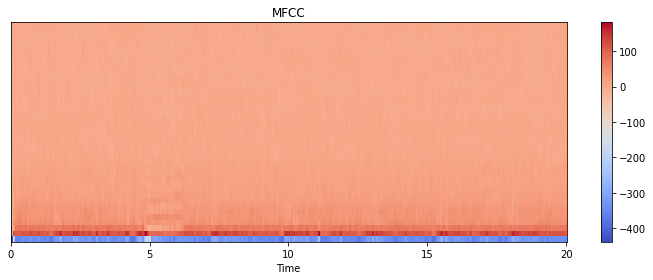

In [ ]:
# plot an MFCC
plt.figure(figsize=(10, 4))
librosa.display.specshow(features[7], x_axis='time')
plt.colorbar()
plt.title('MFCC')
plt.tight_layout()
plt.show()

In [ ]:
features = np.array(features) # convert to numpy array

In [ ]:
# Delete the rarer diseases

features1 = np.delete(features, np.where((labels == 'Asthma') | (labels == 'LRTI'))[0], axis=0)

labels1 = np.delete(labels, np.where((labels == 'Asthma') | (labels == 'LRTI'))[0], axis=0)

In [ ]:
# Print class counts
unique_elements, counts_elements = np.unique(labels1, return_counts=True)
print(np.asarray((unique_elements, counts_elements)))

[['Bronchiectasis' 'Bronchiolitis' 'COPD' 'Healthy' 'Pneumonia' 'URTI']
 ['16' '13' '793' '35' '37' '23']]


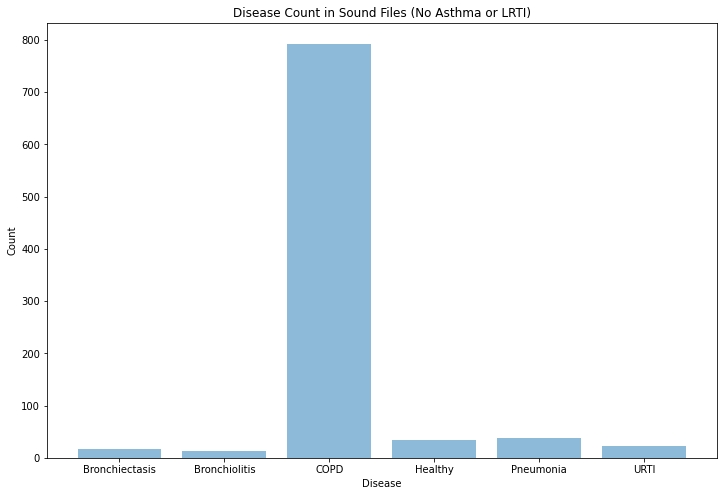

In [ ]:
# Plot class counts
y_pos = np.arange(len(unique_elements))
plt.figure(figsize=(12, 8))
plt.bar(unique_elements, counts_elements, align='center', alpha=0.5)
plt.xticks(y_pos, unique_elements)
plt.ylabel('Count')
plt.xlabel('Disease')
plt.title('Disease Count in Sound Files (No Asthma or LRTI)')
plt.show()

In [ ]:
# One-hot encode labels
le = LabelEncoder()
i_labels = le.fit_transform(labels1)
oh_labels = to_categorical(i_labels)

In [ ]:
# Add channel dimension for CNN
features1 = np.reshape(features1, (*features1.shape,1))

In [ ]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(features1, oh_labels, stratify=oh_labels,
                                                    test_size=0.2, random_state=42)

# Convolutional Neural Network (CNN) model architecture

Our model will be a Convolutional Neural Network (CNN) using Keras and a Tensorflow backend.

**We will use a sequential model, with a simple model architecture, consisting of four Conv2D convolution layers, with our final output layer being a dense layer.**

The convolution layers are designed for feature detection. It works by sliding a filter window over the input and performing a matrix multiplication and storing the result in a feature map. This operation is known as a convolution.

The filter parameter specifies the number of nodes in each layer. Each layer will increase in size from 16, 32, 64 to 128, while the kernel_size parameter specifies the size of the kernel window which in this case is 2 resulting in a 2x2 filter matrix.

**The first layer will receive the input shape of (40, 862, 1) where 40 is the number of MFCC's, 862 is the number of frames taking padding into account and the 1 signifying that the audio is mono.**

**The activation function we will be using for our convolutional layers is ReLU. We will use a small Dropout value of 20% on our convolutional layers.**

Each convolutional layer has an associated pooling layer of **MaxPooling2D** type with the final convolutional layer having a **GlobalAveragePooling2D** type. The pooling layer is to **reduce the dimensionality of the model** (by reducing the parameters and subsequent computation requirements) which serves to **shorten the training time and reduce overfitting**. **The Max Pooling type takes the maximum size for each window and the Global Average Pooling type takes the average which is suitable for feeding into our dense output layer.**

Our output layer will have 6 nodes (num_labels) which matches the number of possible classifications. The activation is for our output layer is **softmax**. Softmax makes the output sum up to 1 so the output can be interpreted as probabilities. The model will then make its prediction based on which option has the highest probability.

In [ ]:
from prompt_toolkit import filters
num_rows = 40
num_columns = 862
num_channels = 1

num_labels = oh_labels.shape[1]
filter_size = 2

# Construct model
model = Sequential()
model.add(Conv2D(filters=16, kernel_size=filter_size,
                 input_shape=(num_rows, num_columns, num_channels),
                 activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=32, kernel_size=filter_size, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=64, kernel_size=filter_size, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=128, kernel_size=filter_size, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(GlobalAveragePooling2D())

model.add(Dense(num_labels, activation='softmax'))

In [ ]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [ ]:
# Display model architecture summary
model.summary()

# Calculate pre-training accuracy
score = model.evaluate(x_test, y_test, verbose=1)
accuracy = 100*score[1]

print("Pre-training accuracy: %.4f%%" % accuracy)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 39, 861, 16)       80        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 19, 430, 16)      0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 19, 430, 16)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 18, 429, 32)       2080      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 9, 214, 32)       0         
 2D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 9, 214, 32)        0

#Training

Here we will train the model. If we have a trained model, we can load it instead from the next cell.

In [ ]:
# Train model
num_epochs = 250
num_batch_size = 128

start = datetime.now()

model.fit(x_train, y_train, batch_size=num_batch_size, epochs=num_epochs,
          validation_data=(x_test, y_test), verbose=1)

duration = datetime.now() - start
print("Training completed in time: ", duration)

Epoch 1/250
6/6 [==============================] - 25s 4s/step - loss: 3.2176 - accuracy: 0.6671 - val_loss: 1.4691 - val_accuracy: 0.8641
Epoch 2/250
6/6 [==============================] - 25s 4s/step - loss: 3.0482 - accuracy: 0.8308 - val_loss: 1.0810 - val_accuracy: 0.8641
Epoch 3/250
6/6 [==============================] - 23s 4s/step - loss: 1.8893 - accuracy: 0.8254 - val_loss: 1.1302 - val_accuracy: 0.7120
Epoch 4/250
6/6 [==============================] - 24s 4s/step - loss: 1.2490 - accuracy: 0.8226 - val_loss: 0.7763 - val_accuracy: 0.8641
Epoch 5/250
6/6 [==============================] - 23s 4s/step - loss: 1.0296 - accuracy: 0.8445 - val_loss: 0.7326 - val_accuracy: 0.8641
Epoch 6/250
6/6 [==============================] - 23s 4s/step - loss: 0.7437 - accuracy: 0.8554 - val_loss: 0.8248 - val_accuracy: 0.8207
Epoch 7/250
6/6 [==============================] - 25s 4s/step - loss: 0.6057 - accuracy: 0.8445 - val_loss: 1.0196 - val_accuracy: 0.6793
Epoch 8/250
6/6 [==========

# Test the model

Here we will review the accuracy of the model on both the training and test data sets.

In [ ]:
# Load model
model = load_model('./CNN-MFCC.h5')

In [ ]:
# Evaluating the model on the training and testing set
score = model.evaluate(x_train, y_train, verbose=0)
print("Training Accuracy: ", score[1])

score = model.evaluate(x_test, y_test, verbose=0)
print("Testing Accuracy: ", score[1])

Training Accuracy:  0.9427012205123901
Testing Accuracy:  0.9510869383811951


In [ ]:
preds = model.predict(x_test) # label scores

classpreds = np.argmax(preds, axis=1) # predicted classes

y_testclass = np.argmax(y_test, axis=1) # true classes

n_classes=6 # number of classes

6/6 [==============================] - 1s 201ms/step


In [ ]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [ ]:
c_names = ['Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Pneumonia', 'URTI']

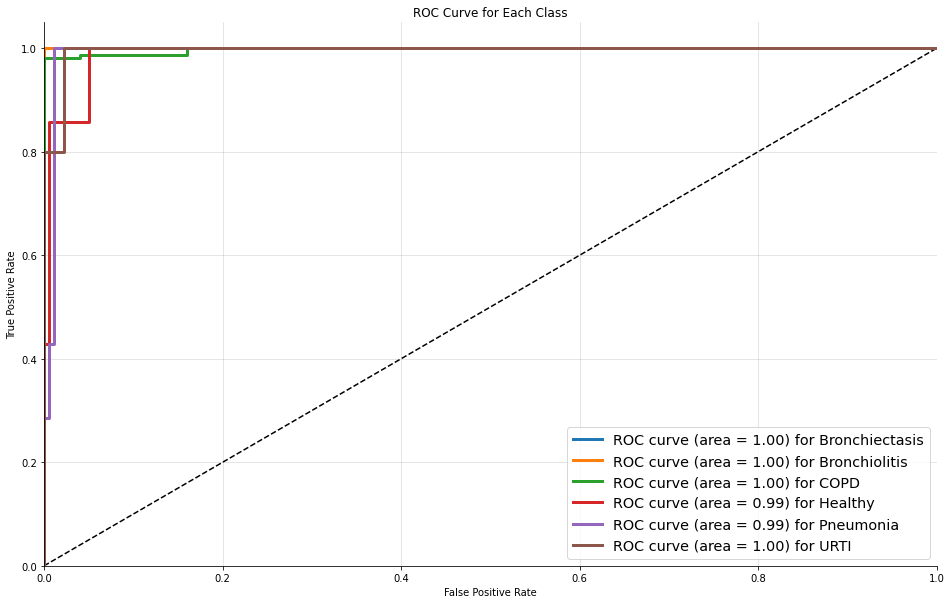

In [ ]:
# Plot ROC curves
fig, ax = plt.subplots(figsize=(16, 10))
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve for Each Class')
for i in range(n_classes):
    ax.plot(fpr[i], tpr[i], linewidth=3, label='ROC curve (area = %0.2f) for %s' % (roc_auc[i], c_names[i]))
ax.legend(loc="best", fontsize='x-large')
ax.grid(alpha=.4)
sns.despine()
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_testclass, classpreds, target_names=c_names))

                precision    recall  f1-score   support

Bronchiectasis       1.00      1.00      1.00         3
 Bronchiolitis       0.60      1.00      0.75         3
          COPD       0.98      1.00      0.99       159
       Healthy       0.75      0.43      0.55         7
     Pneumonia       0.75      0.43      0.55         7
          URTI       0.80      0.80      0.80         5

      accuracy                           0.95       184
     macro avg       0.81      0.78      0.77       184
  weighted avg       0.95      0.95      0.95       184



In [ ]:
# Confusion Matrix
print(confusion_matrix(y_testclass, classpreds))

[[  3   0   0   0   0   0]
 [  0   3   0   0   0   0]
 [  0   0 159   0   0   0]
 [  0   1   1   3   1   1]
 [  0   1   3   0   3   0]
 [  0   0   0   1   0   4]]


In [ ]:
model.save("./drive/MyDrive/"Colab Notebooks"")

# Testing

In [ ]:
# load the saved model
model_test = load_model('./CNN-MFCC.h5')

In [ ]:
# Display model architecture summary
model.summary()

# Calculate pre-training accuracy
score = model.evaluate(x_test, y_test, verbose=1)
accuracy = 100*score[1]

print("Pre-training accuracy: %.4f%%" % accuracy)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 39, 861, 16)       80        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 19, 430, 16)      0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 19, 430, 16)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 18, 429, 32)       2080      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 9, 214, 32)       0         
 2D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 9, 214, 32)        0

In [ ]:
model.predict(x_test)

6/6 [==============================] - 1s 222ms/step


array([[3.72658349e-09, 1.40404358e-13, 9.99999940e-01, 1.62295297e-26,
        1.03025734e-10, 2.63829437e-19],
       [1.51782124e-12, 3.18954458e-14, 9.99999940e-01, 1.61338025e-13,
        5.89606941e-08, 3.55711229e-12],
       [1.17987710e-20, 6.87807504e-19, 9.99999940e-01, 0.00000000e+00,
        3.97639784e-27, 0.00000000e+00],
       ...,
       [5.30044588e-07, 2.18854282e-07, 3.21951433e-04, 1.09495136e-13,
        9.99676943e-01, 3.81250629e-07],
       [7.25735347e-08, 2.29135333e-09, 9.99999821e-01, 4.89485872e-20,
        2.48973819e-08, 1.54102788e-14],
       [4.79353388e-04, 9.29112196e-01, 1.53023120e-05, 1.37112220e-04,
        3.57026164e-03, 6.66856840e-02]], dtype=float32)

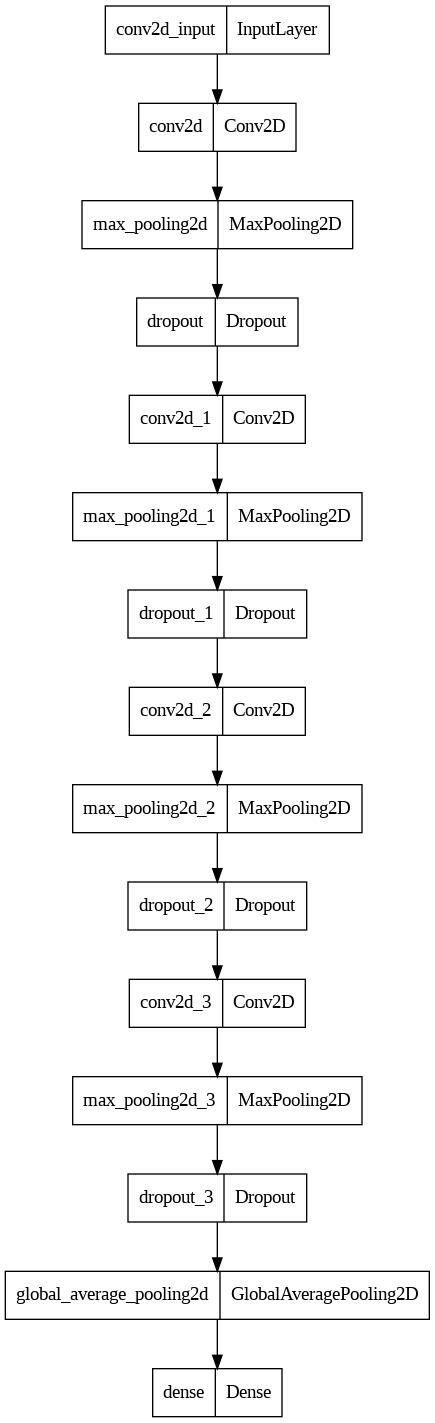

In [ ]:
plot_model(model)

In [ ]:
# Predict with class
'''
pred1 = model.predict(x_train)
classpred1 = np.argmax(pred1)
'''
c_pred = np.argmax(preds)
labels1[c_pred]
c_pred

NameError: ignored

In [ ]:
classpreds

array([2, 2, 2, 2, 2, 2, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3,
       4, 2, 2, 2, 2, 2, 2, 5, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 2, 2, 2, 2, 2, 2, 1, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 5, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 4, 2, 1])

In [ ]:
model.evaluate(x_train, y_train, verbose=1)

23/23 [==============================] - 9s 373ms/step - loss: 0.3048 - accuracy: 0.9427


[0.3047507703304291, 0.9427012205123901]

In [ ]:
model.get_metrics_result()

{'loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.30475077>,
 'accuracy': <tf.Tensor: shape=(), dtype=float32, numpy=0.9427012>}